# 12 — Multimodal Concatenation Baselines

Two tiers of concatenation baselines:

**Tier 1 — Raw concat** (arms 1–4): feature vectors concatenated directly into a shared MLP.

**Tier 2 — Encoder-projected concat** (arms 5–7): each modality projected to 256-d via a
small MLP encoder before concatenation. Controls for encoder projection vs attention in nb13.

| Arm | Modalities | Integration |
|-----|-----------|-------------|
| 1 | rna + protein | raw concat |
| 2 | rna + drug_fp | raw concat |
| 3 | protein + drug_fp | raw concat |
| 4 | rna + protein + drug_fp | raw concat |
| 5 | rna + drug_fp | encoder → concat |
| 6 | protein + drug_fp | encoder → concat |
| 7 | rna + protein + drug_fp | encoder → concat |

## Environment setup (Colab or local)

In [41]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q torch-geometric rdkit
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/multiomics_project


## GPU check

In [42]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cpu':
    print('WARNING: no GPU detected — Runtime > Change runtime type > GPU')

Device: cuda


## Imports and config

In [ ]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.metrics import r2_score, roc_auc_score
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR       = BASE_PATH / 'data' / 'GDSC2'
PROCESSED_DIR  = BASE_PATH / 'data' / 'processed'
SPLITS_DIR     = BASE_PATH / 'data' / 'splits'
RESULTS_DIR    = BASE_PATH / 'results' / 'concat_multimodal'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'checkpoints').mkdir(exist_ok=True)

COL_CELL_LINE   = 'cell_line_name'
COL_DRUG        = 'drug_name'
COL_IC50        = 'LN_IC50'
COL_CELLOSAURUS = 'cellosaurus_id'
COL_TISSUE      = 'tissue'

TOP_K_FEATURES   = 1000  # applied to RNA and protein independently
VALIDATION_RATIO = 0.1
RANDOM_STATE     = 42

# Set to True to run only fold 0 / LCO for a quick smoke test
QUICK_TEST = True

## Load response pairs and splits

In [ ]:
pairs = pd.read_parquet(PROCESSED_DIR / 'response_pairs.parquet')

with open(SPLITS_DIR / 'splits.json') as f:
    folds = json.load(f)

with open(SPLITS_DIR / 'holdout_groups.json') as f:
    holdout_groups = json.load(f)

print(f'{len(pairs):,} pairs loaded')
for fd in folds:
    print(f"fold {fd['fold']}: train={len(fd['train']):,} | "
          f"lco={len(fd['lco_test']):,} | ldo={len(fd['ldo_test']):,} | "
          f"lto={len(fd['lto_test']):,} | lpo={len(fd['lpo_test']):,}")

## Load omics features and drug fingerprints

In [ ]:
rna         = pd.read_csv(DATA_DIR / 'gene_expression.csv',  index_col=0)
protein     = pd.read_csv(DATA_DIR / 'proteomics.csv',        index_col=0)
drug_smiles = pd.read_csv(DATA_DIR / 'drug_smiles.csv')

# Deduplicate immediately — duplicate cellosaurus_id rows cause silent row-count mismatches
rna     = rna[~rna.index.duplicated(keep='first')].iloc[:, 1:]
protein = protein[~protein.index.duplicated(keep='first')].fillna(0)

OMICS = {'rna': rna, 'protein': protein}

print(f'RNA:     {rna.shape[1]:,} genes    x {rna.shape[0]:,} cell lines')
print(f'Protein: {protein.shape[1]:,} proteins x {protein.shape[0]:,} cell lines')
print(f'Drugs:   {drug_smiles[COL_DRUG].nunique():,}')

In [ ]:
def build_drug_fingerprints(drug_smiles_df: pd.DataFrame,
                             radius: int = 2,
                             n_bits: int = 2048) -> dict:
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = {}
    for _, row in drug_smiles_df.iterrows():
        mol = Chem.MolFromSmiles(row['canonical_smiles'])
        if mol is None:
            continue
        fps[row[COL_DRUG]] = np.array(generator.GetFingerprint(mol), dtype=np.float32)
    return fps

drug_fp = build_drug_fingerprints(drug_smiles)
print(f'Fingerprints: {len(drug_fp):,} drugs | dim={next(iter(drug_fp.values())).shape[0]}')

## Train / validation split

In [ ]:
def make_validation_indices(train_idx: np.ndarray,
                             fraction: float = VALIDATION_RATIO,
                             seed: int = RANDOM_STATE):
    """Hold out a fraction of cell lines, drugs, and tissues from train.
    Same construction as notebook 09 so inner-val sets are comparable."""
    sub = pairs.loc[train_idx]

    def axis_holdout(group_values: pd.Series, seed_offset: int) -> set:
        gss = GroupShuffleSplit(n_splits=1, test_size=fraction,
                                random_state=seed + seed_offset)
        _, val_idx = next(gss.split(np.arange(len(group_values)),
                                    groups=group_values))
        return set(group_values.iloc[val_idx])

    cell_ho   = axis_holdout(sub[COL_CELLOSAURUS], 0)
    drug_ho   = axis_holdout(sub[COL_DRUG],        1)
    tissue_ho = axis_holdout(sub[COL_TISSUE],      2)

    is_val = (
        sub[COL_CELLOSAURUS].isin(cell_ho)
        | sub[COL_DRUG].isin(drug_ho)
        | sub[COL_TISSUE].isin(tissue_ho)
    ).to_numpy()

    return train_idx[~is_val], train_idx[is_val]

train_inner_idx, val_idx = make_validation_indices(np.array(folds[0]['train']))
print(f'train_inner: {len(train_inner_idx):,} | val: {len(val_idx):,}')

## Feature selection

Top-K variance features computed from train cell lines only. Fitted once on the outer train fold and reused for all four arms.

In [ ]:
def select_top_variance_omics(arm: str,
                               train_idx: np.ndarray,
                               k: int) -> pd.Index:
    """Return top-k highest-variance column names for an omics arm.
    Variance is computed over train cell lines only to avoid leakage."""
    train_cells = pairs.loc[train_idx, COL_CELLOSAURUS].unique()
    compact = OMICS[arm].loc[OMICS[arm].index.intersection(train_cells)]
    return compact.var(axis=0).sort_values(ascending=False).index[:k]

top_cols = {
    'rna':     select_top_variance_omics('rna',     np.array(folds[0]['train']), TOP_K_FEATURES),
    'protein': select_top_variance_omics('protein', np.array(folds[0]['train']), TOP_K_FEATURES),
}
print(f"Selected {len(top_cols['rna']):,} RNA features, {len(top_cols['protein']):,} protein features")

## DataLoader helpers

In [ ]:
def build_feature_matrix(idx: np.ndarray, top_cols: dict) -> dict:
    """Build per-modality numpy arrays for a set of pair indices.
    top_cols must be fitted on the train fold before calling on val/test.
    Returns dict with keys 'rna', 'protein', 'drug', 'y'.
    """
    sub   = pairs.loc[idx]
    cells = sub[COL_CELLOSAURUS]

    rna_X     = OMICS['rna'].loc[cells, top_cols['rna']].to_numpy().astype(np.float32)
    protein_X = OMICS['protein'].loc[cells, top_cols['protein']].to_numpy().astype(np.float32)
    drug_X    = np.vstack([drug_fp[d] for d in sub[COL_DRUG]]).astype(np.float32)
    y         = sub[COL_IC50].to_numpy().astype(np.float32)

    assert not np.isnan(rna_X).any(),     'NaNs in RNA'
    assert not np.isnan(protein_X).any(), 'NaNs in protein'
    assert not np.isnan(y).any(),         'NaNs in target'

    return {'rna': rna_X, 'protein': protein_X, 'drug': drug_X, 'y': y}


def make_dataloader(matrices: dict,
                    arm_keys: list,
                    batch_size: int,
                    shuffle: bool) -> DataLoader:
    """arm_keys: subset of ['rna', 'protein', 'drug'] in concatenation order.
    y is always appended as the last tensor.
    """
    tensors = [torch.from_numpy(matrices[k]) for k in arm_keys]
    tensors.append(torch.from_numpy(matrices['y']))
    dataset = TensorDataset(*tensors)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)

In [43]:
# Build feature matrices once — shared across all four arms
print('Building train matrices...')
train_matrices = build_feature_matrix(train_inner_idx, top_cols)
print('Building val matrices...')
val_matrices   = build_feature_matrix(val_idx,          top_cols)

print('Building test matrices...')
lco_matrices = build_feature_matrix(np.array(folds[0]['lco_test']), top_cols)
ldo_matrices = build_feature_matrix(np.array(folds[0]['ldo_test']), top_cols)
lto_matrices = build_feature_matrix(np.array(folds[0]['lto_test']), top_cols)
lpo_matrices = build_feature_matrix(np.array(folds[0]['lpo_test']), top_cols)

print('Done.')
for name, m in [('train', train_matrices), ('val', val_matrices), ('lco', lco_matrices)]:
    print(f"  {name}: rna={m['rna'].shape}, protein={m['protein'].shape}, "
          f"drug={m['drug'].shape}, y={m['y'].shape}")

Building train matrices...
Building val matrices...
Building test matrices...
Done.
  train: rna=(79187, 1000), protein=(79187, 1000), drug=(79187, 2048), y=(79187,)
  val: rna=(28234, 1000), protein=(28234, 1000), drug=(28234, 2048), y=(28234,)
  lco: rna=(17470, 1000), protein=(17470, 1000), drug=(17470, 2048), y=(17470,)


## `ConcatMLP` architecture

Concatenates any combination of input feature vectors, then passes through a
standard BN → Dropout → ReLU MLP. Identical internal structure to `NN1Omics`
in notebook 09 — `input_dim` is simply `sum(input_dims)`. This is the naive concatenation baseline.

In [ ]:
class ConcatMLP(nn.Module):
    """Naive concatenation multimodal MLP.

    input_dims   : list of ints, one per modality in concatenation order.
    hidden_layers: list of hidden layer widths.
    dropout_prob : applied after BN on every layer except the last hidden layer.
    """

    def __init__(self, input_dims: list, hidden_layers: list, dropout_prob: float = 0.3):
        super().__init__()
        total_dim = sum(input_dims)

        self.fc_layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()

        self.fc_layers.append(nn.Linear(total_dim, hidden_layers[0]))
        self.bn_layers.append(nn.BatchNorm1d(hidden_layers[0]))
        for i in range(1, len(hidden_layers)):
            self.fc_layers.append(nn.Linear(hidden_layers[i - 1], hidden_layers[i]))
            self.bn_layers.append(nn.BatchNorm1d(hidden_layers[i]))

        # Final prediction layer — no BN, no dropout (matches NN1Omics in nb 09)
        self.fc_layers.append(nn.Linear(hidden_layers[-1], 1))
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, *inputs):
        x = torch.cat(inputs, dim=1)
        for i in range(len(self.fc_layers) - 2):
            x = self.fc_layers[i](x)
            x = self.bn_layers[i](x)
            x = self.dropout(x)
            x = F.relu(x)
        x = F.relu(self.fc_layers[-2](x))  # last hidden: no BN/dropout
        return self.fc_layers[-1](x).squeeze(-1)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training loop

In [ ]:
def fit_concat_mlp(model: nn.Module,
                   train_loader: DataLoader,
                   val_loader: DataLoader,
                   arm_keys: list,
                   num_epochs: int,
                   patience: int,
                   checkpoint_path: Path,
                   device: torch.device):
    """arm_keys: modality keys in DataLoader tensor order (y is always the last tensor)."""
    criterion = nn.HuberLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

    history = {'train_loss': [], 'train_cor': [], 'val_loss': [], 'val_cor': []}
    best_val_loss = float('inf')
    best_weights  = None
    wait          = 0

    print(f"Training arm: {' + '.join(arm_keys)} | params: {count_parameters(model):,}")

    for epoch in range(num_epochs):
        for phase in ['val', 'train']:
            loader = train_loader if phase == 'train' else val_loader
            phase_device = device if phase == 'train' else torch.device('cpu')
            model.to(phase_device)
            model.train() if phase == 'train' else model.eval()

            batch_losses, preds, targets = [], [], []

            for batch in tqdm(loader, desc=f'epoch {epoch+1} {phase}', leave=False):
                # Last tensor in batch is y; all preceding tensors are modality features
                *modality_tensors, y = [t.to(phase_device) for t in batch]

                if phase == 'train':
                    optimizer.zero_grad()
                    pred = model(*modality_tensors)
                    loss = criterion(pred, y)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        pred = model(*modality_tensors)
                        loss = criterion(pred, y)

                batch_losses.append(loss.item())
                preds.append(pred.detach())
                targets.append(y.detach())

            epoch_loss = sum(batch_losses) / len(batch_losses)
            all_preds   = torch.cat(preds).cpu().numpy()
            all_targets = torch.cat(targets).cpu().numpy()
            epoch_cor, _ = pearsonr(all_targets, all_preds)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_cor'].append(epoch_cor)

            if phase == 'val':
                print(f'  epoch {epoch+1:>3} | val loss={epoch_loss:.4f}  pearson_r={epoch_cor:.4f}')
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        print(f'  Early stopping at epoch {epoch + 1}')
                        model.load_state_dict(best_weights)
                        torch.save(best_weights, checkpoint_path)
                        print(f'  Best val loss: {best_val_loss:.4f} -> saved to {checkpoint_path}')
                        return model, history

    model.load_state_dict(best_weights)
    torch.save(best_weights, checkpoint_path)
    print(f'  Best val loss: {best_val_loss:.4f} -> saved to {checkpoint_path}')
    return model, history

## Prediction and evaluation helpers

In [ ]:
def predict_concat(model: nn.Module,
                   matrices: dict,
                   arm_keys: list,
                   batch_size: int = 512,
                   device: str = 'cpu') -> np.ndarray:
    """Run inference on a pre-built feature matrix dict.
    Returns predictions as a 1-D numpy array.
    """
    model.to(device)
    model.eval()
    tensors = [torch.from_numpy(matrices[k]) for k in arm_keys]
    n = tensors[0].shape[0]
    preds = []
    with torch.no_grad():
        for i in range(0, n, batch_size):
            batch_inputs = [t[i:i + batch_size].to(device) for t in tensors]
            preds.append(model(*batch_inputs).cpu())
    return torch.cat(preds).numpy()

In [46]:
def evaluate_split(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Returns a flat dict of metrics for one split."""
    corr,  corr_p  = pearsonr(y_true, y_pred)
    spear, spear_p = spearmanr(y_true, y_pred)
    mse            = float(np.mean((y_true - y_pred) ** 2))
    rmse           = float(np.sqrt(mse))
    r2             = float(r2_score(y_true, y_pred))
    slope, _, _, _, std_err = linregress(y_pred, y_true)
    threshold = np.median(y_true)
    binary    = (y_true < threshold).astype(int)
    roc = roc_auc_score(binary, -y_pred) if len(np.unique(binary)) == 2 else np.nan
    return {
        'Pearson r':  round(corr,     4),
        'Spearman r': round(spear,    4),
        'RMSE':       round(rmse,     4),
        'R2':         round(r2,       4),
        'ROC-AUC':    round(roc, 4) if not np.isnan(roc) else roc,
        'Slope':      round(slope,    4),
        'Std err':    round(std_err,  4),
    }


def evaluate_all_splits(arm_name: str, preds: dict) -> pd.DataFrame:
    """preds: dict of split_name -> (y_true, y_pred).
    For 'LPO', the full array is evaluated as 'LPO - all', then each
    lpo_masks sub-split is evaluated separately.
    """
    rows = []
    for split_name, (y_true, y_pred) in preds.items():
        if split_name == 'LPO':
            # Overall LPO
            row = {'arm': arm_name, 'split': 'LPO - all'}
            row.update(evaluate_split(y_true, y_pred))
            rows.append(row)
            # Sub-splits by novelty
            for mask_name, mask in lpo_masks.items():
                if mask.sum() == 0:
                    continue
                row = {'arm': arm_name, 'split': mask_name}
                row.update(evaluate_split(y_true[mask], y_pred[mask]))
                rows.append(row)
        else:
            row = {'arm': arm_name, 'split': split_name}
            row.update(evaluate_split(y_true, y_pred))
            rows.append(row)
    return pd.DataFrame(rows)

In [44]:
def build_lpo_masks(fold_idx: int = 0) -> dict:
    cell_holdout = set(holdout_groups[fold_idx]['cell_lines_held_out'])
    drug_holdout = set(holdout_groups[fold_idx]['drugs_held_out'])
    lpo_idx = np.array(folds[fold_idx]['lpo_test'])
    sub = pairs.loc[lpo_idx]
    is_new_cell = sub[COL_CELLOSAURUS].isin(cell_holdout).to_numpy()
    is_new_drug = sub[COL_DRUG].isin(drug_holdout).to_numpy()
    masks = {
        'LPO - nothing new':           (~is_new_cell) & (~is_new_drug),
        'LPO - new cell line only':     is_new_cell   & (~is_new_drug),
        'LPO - new drug only':          (~is_new_cell) & is_new_drug,
        'LPO - fully new (cell+drug)':  is_new_cell   & is_new_drug,
    }
    for name, mask in masks.items():
        print(f'{name}: n={mask.sum():,}')
    return masks

lpo_masks = build_lpo_masks(fold_idx=0)

LPO - nothing new: n=16,599
LPO - new cell line only: n=1,823
LPO - new drug only: n=1,971
LPO - fully new (cell+drug): n=220


## Shared hyperparameters

In [ ]:
HIDDEN_LAYERS = [512, 256]
DROPOUT       = 0.3
BATCH_SIZE    = 64
NUM_EPOCHS    = 100
PATIENCE      = 10

DIM_RNA     = train_matrices['rna'].shape[1]
DIM_PROTEIN = train_matrices['protein'].shape[1]
DIM_DRUG_FP = train_matrices['drug'].shape[1]

print(f'RNA dim: {DIM_RNA} | Protein dim: {DIM_PROTEIN} | Drug FP dim: {DIM_DRUG_FP}')

---
## Arm 1 — RNA + Protein

In [ ]:
ARM1_KEYS = ['rna', 'protein']
arm1_train_loader = make_dataloader(train_matrices, ARM1_KEYS, BATCH_SIZE, shuffle=True)
arm1_val_loader   = make_dataloader(val_matrices,   ARM1_KEYS, BATCH_SIZE, shuffle=False)

In [ ]:
arm1_model = ConcatMLP(
    input_dims=[DIM_RNA, DIM_PROTEIN],
    hidden_layers=HIDDEN_LAYERS,
    dropout_prob=DROPOUT,
)
print(f'Arm 1 (rna+protein) parameters: {count_parameters(arm1_model):,}')

In [ ]:
arm1_model, arm1_history = fit_concat_mlp(
    model=arm1_model,
    train_loader=arm1_train_loader,
    val_loader=arm1_val_loader,
    arm_keys=ARM1_KEYS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'arm1_rna_protein.pt',
    device=DEVICE,
)

In [47]:
arm1_preds = {
    'LCO': (lco_matrices['y'], predict_concat(arm1_model, lco_matrices, ARM1_KEYS)),
    'LDO': (ldo_matrices['y'], predict_concat(arm1_model, ldo_matrices, ARM1_KEYS)),
    'LTO': (lto_matrices['y'], predict_concat(arm1_model, lto_matrices, ARM1_KEYS)),
    'LPO': (lpo_matrices['y'], predict_concat(arm1_model, lpo_matrices, ARM1_KEYS)),
}
arm1_results = evaluate_all_splits('rna+protein', arm1_preds)
arm1_results

,arm,split,Pearson r,Spearman r,RMSE,R2,ROC-AUC,Slope,Std err
0,rna+protein,LCO,0.2052,0.2310,2.7509,-0.0562,0.6136,1.0005,0.0361
1,rna+protein,LDO,0.2786,0.3161,2.5513,0.0017,0.6506,1.0857,0.0276
2,rna+protein,LTO,0.2189,0.2261,2.8728,-0.0940,0.6015,1.2318,0.0341
3,rna+protein,LPO - all,0.2905,0.3104,2.6967,-0.0004,0.6483,1.1931,0.0274
4,rna+protein,LPO - nothing new,0.3033,0.3210,2.7118,0.0087,0.6548,1.2362,0.0301
5,rna+protein,LPO - new cell line only,0.1728,0.2010,2.7651,-0.0685,0.5940,0.8470,0.1132
6,rna+protein,LPO - new drug only,0.2826,0.3314,2.4907,-0.0110,0.6601,1.0575,0.0809
7,rna+protein,LPO - fully new (cell+drug),0.1907,0.2503,2.7549,-0.0791,0.5862,0.9617,0.3352


---
## Arm 2 — RNA + Drug FP

In [ ]:
ARM2_KEYS = ['rna', 'drug']
arm2_train_loader = make_dataloader(train_matrices, ARM2_KEYS, BATCH_SIZE, shuffle=True)
arm2_val_loader   = make_dataloader(val_matrices,   ARM2_KEYS, BATCH_SIZE, shuffle=False)

In [ ]:
arm2_model = ConcatMLP(
    input_dims=[DIM_RNA, DIM_DRUG_FP],
    hidden_layers=HIDDEN_LAYERS,
    dropout_prob=DROPOUT,
)
print(f'Arm 2 (rna+drug_fp) parameters: {count_parameters(arm2_model):,}')

In [ ]:
arm2_model, arm2_history = fit_concat_mlp(
    model=arm2_model,
    train_loader=arm2_train_loader,
    val_loader=arm2_val_loader,
    arm_keys=ARM2_KEYS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'arm2_rna_drug.pt',
    device=DEVICE,
)

In [48]:
arm2_preds = {
    'LCO': (lco_matrices['y'], predict_concat(arm2_model, lco_matrices, ARM2_KEYS)),
    'LDO': (ldo_matrices['y'], predict_concat(arm2_model, ldo_matrices, ARM2_KEYS)),
    'LTO': (lto_matrices['y'], predict_concat(arm2_model, lto_matrices, ARM2_KEYS)),
    'LPO': (lpo_matrices['y'], predict_concat(arm2_model, lpo_matrices, ARM2_KEYS)),
}
arm2_results = evaluate_all_splits('rna+drug_fp', arm2_preds)
arm2_results

,arm,split,Pearson r,Spearman r,RMSE,R2,ROC-AUC,Slope,Std err
0,rna+drug_fp,LCO,0.7643,0.7033,1.7329,0.5809,0.8481,0.9361,0.0060
1,rna+drug_fp,LDO,0.3217,0.3097,2.4323,0.0927,0.6436,0.7642,0.0166
2,rna+drug_fp,LTO,0.7864,0.7319,1.7031,0.6155,0.8552,0.9531,0.0046
3,rna+drug_fp,LPO - all,0.8058,0.7582,1.5982,0.6486,0.8727,0.9676,0.0050
4,rna+drug_fp,LPO - nothing new,0.8434,0.8038,1.4643,0.7110,0.8957,0.9775,0.0048
5,rna+drug_fp,LPO - new cell line only,0.8005,0.7347,1.6135,0.6362,0.8645,0.9264,0.0163
6,rna+drug_fp,LPO - new drug only,0.3361,0.3324,2.3493,0.1004,0.6537,0.7757,0.0490
7,rna+drug_fp,LPO - fully new (cell+drug),0.2839,0.2742,2.5560,0.0711,0.6314,0.7984,0.1826


---
## Arm 3 — Protein + Drug FP

In [ ]:
ARM3_KEYS = ['protein', 'drug']
arm3_train_loader = make_dataloader(train_matrices, ARM3_KEYS, BATCH_SIZE, shuffle=True)
arm3_val_loader   = make_dataloader(val_matrices,   ARM3_KEYS, BATCH_SIZE, shuffle=False)

In [ ]:
arm3_model = ConcatMLP(
    input_dims=[DIM_PROTEIN, DIM_DRUG_FP],
    hidden_layers=HIDDEN_LAYERS,
    dropout_prob=DROPOUT,
)
print(f'Arm 3 (protein+drug_fp) parameters: {count_parameters(arm3_model):,}')

In [ ]:
arm3_model, arm3_history = fit_concat_mlp(
    model=arm3_model,
    train_loader=arm3_train_loader,
    val_loader=arm3_val_loader,
    arm_keys=ARM3_KEYS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'arm3_protein_drug.pt',
    device=DEVICE,
)

In [49]:
arm3_preds = {
    'LCO': (lco_matrices['y'], predict_concat(arm3_model, lco_matrices, ARM3_KEYS)),
    'LDO': (ldo_matrices['y'], predict_concat(arm3_model, ldo_matrices, ARM3_KEYS)),
    'LTO': (lto_matrices['y'], predict_concat(arm3_model, lto_matrices, ARM3_KEYS)),
    'LPO': (lpo_matrices['y'], predict_concat(arm3_model, lpo_matrices, ARM3_KEYS)),
}
arm3_results = evaluate_all_splits('protein+drug_fp', arm3_preds)
arm3_results

,arm,split,Pearson r,Spearman r,RMSE,R2,ROC-AUC,Slope,Std err
0,protein+drug_fp,LCO,0.7423,0.6842,1.8320,0.5316,0.8387,0.9257,0.0063
1,protein+drug_fp,LDO,0.2687,0.2809,2.5249,0.0223,0.6314,0.6143,0.0162
2,protein+drug_fp,LTO,0.7632,0.7094,1.7834,0.5784,0.8432,0.9842,0.0052
3,protein+drug_fp,LPO - all,0.7886,0.7440,1.6849,0.6095,0.8655,0.9745,0.0053
4,protein+drug_fp,LPO - nothing new,0.8289,0.7925,1.5477,0.6771,0.8901,0.9905,0.0052
5,protein+drug_fp,LPO - new cell line only,0.7826,0.7135,1.7063,0.5931,0.8496,0.9318,0.0174
6,protein+drug_fp,LPO - new drug only,0.2836,0.2963,2.4468,0.0243,0.6412,0.6397,0.0487
7,protein+drug_fp,LPO - fully new (cell+drug),0.1616,0.1842,2.7379,-0.0657,0.5763,0.4163,0.1722


---
## Arm 4 — RNA + Protein + Drug FP

In [ ]:
ARM4_KEYS = ['rna', 'protein', 'drug']
arm4_train_loader = make_dataloader(train_matrices, ARM4_KEYS, BATCH_SIZE, shuffle=True)
arm4_val_loader   = make_dataloader(val_matrices,   ARM4_KEYS, BATCH_SIZE, shuffle=False)

In [ ]:
arm4_model = ConcatMLP(
    input_dims=[DIM_RNA, DIM_PROTEIN, DIM_DRUG_FP],
    hidden_layers=HIDDEN_LAYERS,
    dropout_prob=DROPOUT,
)
print(f'Arm 4 (rna+protein+drug_fp) parameters: {count_parameters(arm4_model):,}')

In [ ]:
arm4_model, arm4_history = fit_concat_mlp(
    model=arm4_model,
    train_loader=arm4_train_loader,
    val_loader=arm4_val_loader,
    arm_keys=ARM4_KEYS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'arm4_rna_protein_drug.pt',
    device=DEVICE,
)

In [50]:
arm4_preds = {
    'LCO': (lco_matrices['y'], predict_concat(arm4_model, lco_matrices, ARM4_KEYS)),
    'LDO': (ldo_matrices['y'], predict_concat(arm4_model, ldo_matrices, ARM4_KEYS)),
    'LTO': (lto_matrices['y'], predict_concat(arm4_model, lto_matrices, ARM4_KEYS)),
    'LPO': (lpo_matrices['y'], predict_concat(arm4_model, lpo_matrices, ARM4_KEYS)),
}
arm4_results = evaluate_all_splits('rna+protein+drug_fp', arm4_preds)
arm4_results

,arm,split,Pearson r,Spearman r,RMSE,R2,ROC-AUC,Slope,Std err
0,rna+protein+drug_fp,LCO,0.7684,0.6997,1.7238,0.5853,0.8463,0.9439,0.0059
1,rna+protein+drug_fp,LDO,0.3177,0.2934,2.4410,0.0862,0.6312,0.7831,0.0172
2,rna+protein+drug_fp,LTO,0.7879,0.7259,1.7081,0.6133,0.8543,0.9570,0.0046
3,rna+protein+drug_fp,LPO - all,0.8123,0.7608,1.5792,0.6569,0.8751,0.9757,0.0049
4,rna+protein+drug_fp,LPO - nothing new,0.8511,0.8088,1.4349,0.7224,0.8993,0.9841,0.0047
5,rna+protein+drug_fp,LPO - new cell line only,0.8022,0.7325,1.6093,0.6380,0.8659,0.9452,0.0165
6,rna+protein+drug_fp,LPO - new drug only,0.3250,0.3028,2.3686,0.0857,0.6372,0.7815,0.0512
7,rna+protein+drug_fp,LPO - fully new (cell+drug),0.2874,0.2657,2.5633,0.0658,0.6189,0.8430,0.1903


---
## Encoder-projected arms (ablation)

Arms 5–7 project each modality through a small MLP encoder to 256-d **before**
concatenation, then feed the concatenated embeddings into a lightweight predictor MLP.
This isolates the effect of encoder projection from the attention mechanism in nb13:
if these arms improve over arms 2–4, the gain is from projection alone, not attention.

Architecture per modality:
`input → Linear(input_dim, 512) → BN → Dropout → ReLU → Linear(512, 256) → BN → ReLU → 256-d embedding`

Predictor after concat:
`concat_dim → Linear → BN → Dropout → ReLU → Linear → 1`

In [51]:
class OmicsEncoder(nn.Module):
    """Projects a single omics modality to a fixed 256-d embedding."""

    def __init__(self, input_dim: int, hidden: int = 512, out_dim: int = 256,
                 dropout_prob: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout_prob),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DrugMLPEncoder(nn.Module):
    """Projects drug fingerprint (2048-d) to 256-d embedding.
    Same structure as OmicsEncoder — keeps all modalities in the same space
    before concatenation so no single modality dominates by raw feature count.
    """

    def __init__(self, input_dim: int = 2048, hidden: int = 512, out_dim: int = 256,
                 dropout_prob: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout_prob),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class EncodedConcatMLP(nn.Module):
    """Encode each modality to 256-d, concatenate, then predict.

    encoders : list of nn.Module, one per modality in input order.
    n_modalities : number of modalities (sets predictor input dim = n * 256).
    """

    def __init__(self, encoders: list, n_modalities: int,
                 embed_dim: int = 256, dropout_prob: float = 0.3):
        super().__init__()
        self.encoders = nn.ModuleList(encoders)
        concat_dim = embed_dim * n_modalities
        self.predictor = nn.Sequential(
            nn.Linear(concat_dim, concat_dim // 2),
            nn.BatchNorm1d(concat_dim // 2),
            nn.Dropout(dropout_prob),
            nn.ReLU(),
            nn.Linear(concat_dim // 2, 1),
        )

    def forward(self, *inputs):
        embeddings = [enc(x) for enc, x in zip(self.encoders, inputs)]
        return self.predictor(torch.cat(embeddings, dim=1)).squeeze(-1)

In [52]:
def fit_encoded_mlp(model: nn.Module,
                    train_loader: DataLoader,
                    val_loader: DataLoader,
                    arm_keys: list,
                    num_epochs: int,
                    patience: int,
                    checkpoint_path: Path,
                    device: torch.device):
    """Same loop as fit_concat_mlp — reused here without change.
    Kept separate so encoder arms are independently runnable.
    """
    criterion = nn.HuberLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

    history = {'train_loss': [], 'train_cor': [], 'val_loss': [], 'val_cor': []}
    best_val_loss = float('inf')
    best_weights  = None
    wait          = 0

    print(f"Training arm: {' + '.join(arm_keys)} | params: {count_parameters(model):,}")

    for epoch in range(num_epochs):
        for phase in ['val', 'train']:
            loader = train_loader if phase == 'train' else val_loader
            phase_device = device if phase == 'train' else torch.device('cpu')
            model.to(phase_device)
            model.train() if phase == 'train' else model.eval()

            batch_losses, preds, targets = [], [], []

            for batch in tqdm(loader, desc=f'epoch {epoch+1} {phase}', leave=False):
                *modality_tensors, y = [t.to(phase_device) for t in batch]

                if phase == 'train':
                    optimizer.zero_grad()
                    pred = model(*modality_tensors)
                    loss = criterion(pred, y)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        pred = model(*modality_tensors)
                        loss = criterion(pred, y)

                batch_losses.append(loss.item())
                preds.append(pred.detach())
                targets.append(y.detach())

            epoch_loss = sum(batch_losses) / len(batch_losses)
            all_preds   = torch.cat(preds).cpu().numpy()
            all_targets = torch.cat(targets).cpu().numpy()
            epoch_cor, _ = pearsonr(all_targets, all_preds)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_cor'].append(epoch_cor)

            if phase == 'val':
                print(f'  epoch {epoch+1:>3} | val loss={epoch_loss:.4f}  pearson_r={epoch_cor:.4f}')
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        print(f'  Early stopping at epoch {epoch + 1}')
                        model.load_state_dict(best_weights)
                        torch.save(best_weights, checkpoint_path)
                        print(f'  Best val loss: {best_val_loss:.4f} -> saved to {checkpoint_path}')
                        return model, history

    model.load_state_dict(best_weights)
    torch.save(best_weights, checkpoint_path)
    print(f'  Best val loss: {best_val_loss:.4f} -> saved to {checkpoint_path}')
    return model, history


def predict_encoded(model: nn.Module,
                    matrices: dict,
                    arm_keys: list,
                    batch_size: int = 512,
                    device: str = 'cpu') -> np.ndarray:
    """Inference for EncodedConcatMLP — same interface as predict_concat."""
    model.to(device)
    model.eval()
    tensors = [torch.from_numpy(matrices[k]) for k in arm_keys]
    n = tensors[0].shape[0]
    preds = []
    with torch.no_grad():
        for i in range(0, n, batch_size):
            batch_inputs = [t[i:i + batch_size].to(device) for t in tensors]
            preds.append(model(*batch_inputs).cpu())
    return torch.cat(preds).numpy()

---
## Arm 5 — RNA encoder + Drug FP encoder

In [53]:
ARM5_KEYS = ['rna', 'drug']
arm5_train_loader = make_dataloader(train_matrices, ARM5_KEYS, BATCH_SIZE, shuffle=True)
arm5_val_loader   = make_dataloader(val_matrices,   ARM5_KEYS, BATCH_SIZE, shuffle=False)

In [54]:
arm5_model = EncodedConcatMLP(
    encoders=[OmicsEncoder(DIM_RNA), DrugMLPEncoder(DIM_DRUG_FP)],
    n_modalities=2,
)
print(f'Arm 5 (rna_enc+drug_enc) parameters: {count_parameters(arm5_model):,}')

Arm 5 (rna_enc+drug_enc) parameters: 1,959,425


In [55]:
arm5_model, arm5_history = fit_encoded_mlp(
    model=arm5_model,
    train_loader=arm5_train_loader,
    val_loader=arm5_val_loader,
    arm_keys=ARM5_KEYS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'arm5_rna_enc_drug_enc.pt',
    device=DEVICE,
)

Training arm: rna + drug | params: 1,959,425


epoch 1 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch   1 | val loss=3.0127  pearson_r=0.0429


epoch 1 train:   0%|          | 0/1237 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/442 [00:00<?, ?it/s]

...

epoch 12 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch  12 | val loss=0.8850  pearson_r=0.7264


epoch 12 train:   0%|          | 0/1237 [00:00<?, ?it/s]

epoch 13 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch  13 | val loss=0.8912  pearson_r=0.7255
  Early stopping at epoch 13
  Best val loss: 0.8769 -> saved to /content/drive/MyDrive/multiomics_project/results/concat_multimodal/checkpoints/arm5_rna_enc_drug_enc.pt


In [56]:
arm5_preds = {
    'LCO': (lco_matrices['y'], predict_encoded(arm5_model, lco_matrices, ARM5_KEYS)),
    'LDO': (ldo_matrices['y'], predict_encoded(arm5_model, ldo_matrices, ARM5_KEYS)),
    'LTO': (lto_matrices['y'], predict_encoded(arm5_model, lto_matrices, ARM5_KEYS)),
    'LPO': (lpo_matrices['y'], predict_encoded(arm5_model, lpo_matrices, ARM5_KEYS)),
}
arm5_results = evaluate_all_splits('rna_enc+drug_enc', arm5_preds)
arm5_results

,arm,split,Pearson r,Spearman r,RMSE,R2,ROC-AUC,Slope,Std err
0,rna_enc+drug_enc,LCO,0.7963,0.7446,1.6325,0.6281,0.8692,0.9465,0.0054
1,rna_enc+drug_enc,LDO,0.4556,0.4296,2.3211,0.1737,0.6944,1.1266,0.0162
2,rna_enc+drug_enc,LTO,0.8170,0.7718,1.5954,0.6626,0.8799,0.9447,0.0041
3,rna_enc+drug_enc,LPO - all,0.8379,0.7996,1.4811,0.6982,0.8938,0.9722,0.0044
4,rna_enc+drug_enc,LPO - nothing new,0.8728,0.8407,1.3347,0.7598,0.9155,0.9755,0.0042
5,rna_enc+drug_enc,LPO - new cell line only,0.8261,0.7633,1.5219,0.6763,0.8774,0.9390,0.0150
6,rna_enc+drug_enc,LPO - new drug only,0.4631,0.4356,2.2594,0.1680,0.7013,1.1247,0.0485
7,rna_enc+drug_enc,LPO - fully new (cell+drug),0.4208,0.3713,2.4873,0.1204,0.6564,1.3457,0.1965


---
## Arm 6 — Protein encoder + Drug FP encoder

In [57]:
ARM6_KEYS = ['protein', 'drug']
arm6_train_loader = make_dataloader(train_matrices, ARM6_KEYS, BATCH_SIZE, shuffle=True)
arm6_val_loader   = make_dataloader(val_matrices,   ARM6_KEYS, BATCH_SIZE, shuffle=False)

In [58]:
arm6_model = EncodedConcatMLP(
    encoders=[OmicsEncoder(DIM_PROTEIN), DrugMLPEncoder(DIM_DRUG_FP)],
    n_modalities=2,
)
print(f'Arm 6 (protein_enc+drug_enc) parameters: {count_parameters(arm6_model):,}')

Arm 6 (protein_enc+drug_enc) parameters: 1,959,425


In [59]:
arm6_model, arm6_history = fit_encoded_mlp(
    model=arm6_model,
    train_loader=arm6_train_loader,
    val_loader=arm6_val_loader,
    arm_keys=ARM6_KEYS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'arm6_protein_enc_drug_enc.pt',
    device=DEVICE,
)

Training arm: protein + drug | params: 1,959,425


epoch 1 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch   1 | val loss=3.1123  pearson_r=0.1098


epoch 1 train:   0%|          | 0/1237 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/442 [00:00<?, ?it/s]

...

epoch 14 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch  14 | val loss=0.8770  pearson_r=0.7268


epoch 14 train:   0%|          | 0/1237 [00:00<?, ?it/s]

epoch 15 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch  15 | val loss=0.8773  pearson_r=0.7285
  Early stopping at epoch 15
  Best val loss: 0.8644 -> saved to /content/drive/MyDrive/multiomics_project/results/concat_multimodal/checkpoints/arm6_protein_enc_drug_enc.pt


In [60]:
arm6_preds = {
    'LCO': (lco_matrices['y'], predict_encoded(arm6_model, lco_matrices, ARM6_KEYS)),
    'LDO': (ldo_matrices['y'], predict_encoded(arm6_model, ldo_matrices, ARM6_KEYS)),
    'LTO': (lto_matrices['y'], predict_encoded(arm6_model, lto_matrices, ARM6_KEYS)),
    'LPO': (lpo_matrices['y'], predict_encoded(arm6_model, lpo_matrices, ARM6_KEYS)),
}
arm6_results = evaluate_all_splits('protein_enc+drug_enc', arm6_preds)
arm6_results

,arm,split,Pearson r,Spearman r,RMSE,R2,ROC-AUC,Slope,Std err
0,protein_enc+drug_enc,LCO,0.7977,0.7435,1.6321,0.6282,0.8678,0.9295,0.0053
1,protein_enc+drug_enc,LDO,0.4122,0.3547,2.4028,0.1145,0.6538,0.9745,0.0159
2,protein_enc+drug_enc,LTO,0.8060,0.7567,1.6363,0.6451,0.8713,0.9533,0.0043
3,protein_enc+drug_enc,LPO - all,0.8363,0.7959,1.4921,0.6937,0.8919,0.9626,0.0044
4,protein_enc+drug_enc,LPO - nothing new,0.8734,0.8425,1.3339,0.7602,0.9168,0.9710,0.0042
5,protein_enc+drug_enc,LPO - new cell line only,0.8327,0.7750,1.4962,0.6871,0.8849,0.9351,0.0146
6,protein_enc+drug_enc,LPO - new drug only,0.4215,0.3658,2.3467,0.1025,0.6652,0.9901,0.0480
7,protein_enc+drug_enc,LPO - fully new (cell+drug),0.3782,0.3243,2.5460,0.0784,0.6407,1.0635,0.1763


---
## Arm 7 — RNA encoder + Protein encoder + Drug FP encoder

In [61]:
ARM7_KEYS = ['rna', 'protein', 'drug']
arm7_train_loader = make_dataloader(train_matrices, ARM7_KEYS, BATCH_SIZE, shuffle=True)
arm7_val_loader   = make_dataloader(val_matrices,   ARM7_KEYS, BATCH_SIZE, shuffle=False)

In [62]:
arm7_model = EncodedConcatMLP(
    encoders=[OmicsEncoder(DIM_RNA), OmicsEncoder(DIM_PROTEIN), DrugMLPEncoder(DIM_DRUG_FP)],
    n_modalities=3,
)
print(f'Arm 7 (rna_enc+protein_enc+drug_enc) parameters: {count_parameters(arm7_model):,}')

Arm 7 (rna_enc+protein_enc+drug_enc) parameters: 2,769,153


In [63]:
arm7_model, arm7_history = fit_encoded_mlp(
    model=arm7_model,
    train_loader=arm7_train_loader,
    val_loader=arm7_val_loader,
    arm_keys=ARM7_KEYS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'arm7_rna_enc_protein_enc_drug_enc.pt',
    device=DEVICE,
)

Training arm: rna + protein + drug | params: 2,769,153


epoch 1 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch   1 | val loss=3.0850  pearson_r=-0.0081


epoch 1 train:   0%|          | 0/1237 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/442 [00:00<?, ?it/s]

...

epoch 11 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch  11 | val loss=0.8883  pearson_r=0.7221


epoch 11 train:   0%|          | 0/1237 [00:00<?, ?it/s]

epoch 12 val:   0%|          | 0/442 [00:00<?, ?it/s]

  epoch  12 | val loss=0.8981  pearson_r=0.7188
  Early stopping at epoch 12
  Best val loss: 0.8795 -> saved to /content/drive/MyDrive/multiomics_project/results/concat_multimodal/checkpoints/arm7_rna_enc_protein_enc_drug_enc.pt


In [64]:
arm7_preds = {
    'LCO': (lco_matrices['y'], predict_encoded(arm7_model, lco_matrices, ARM7_KEYS)),
    'LDO': (ldo_matrices['y'], predict_encoded(arm7_model, ldo_matrices, ARM7_KEYS)),
    'LTO': (lto_matrices['y'], predict_encoded(arm7_model, lto_matrices, ARM7_KEYS)),
    'LPO': (lpo_matrices['y'], predict_encoded(arm7_model, lpo_matrices, ARM7_KEYS)),
}
arm7_results = evaluate_all_splits('rna_enc+protein_enc+drug_enc', arm7_preds)
arm7_results

,arm,split,Pearson r,Spearman r,RMSE,R2,ROC-AUC,Slope,Std err
0,rna_enc+protein_enc+drug_enc,LCO,0.8021,0.7485,1.6125,0.6371,0.8726,0.9279,0.0052
1,rna_enc+protein_enc+drug_enc,LDO,0.5261,0.4530,2.2227,0.2423,0.7068,1.2082,0.0144
2,rna_enc+protein_enc+drug_enc,LTO,0.8176,0.7728,1.5947,0.6629,0.8814,0.9374,0.0041
3,rna_enc+protein_enc+drug_enc,LPO - all,0.8402,0.8020,1.4745,0.7009,0.8961,0.9480,0.0043
4,rna_enc+protein_enc+drug_enc,LPO - nothing new,0.8711,0.8404,1.3481,0.7550,0.9166,0.9472,0.0041
5,rna_enc+protein_enc+drug_enc,LPO - new cell line only,0.8273,0.7639,1.5210,0.6767,0.8801,0.9153,0.0146
6,rna_enc+protein_enc+drug_enc,LPO - new drug only,0.5342,0.4646,2.1614,0.2386,0.7172,1.2113,0.0432
7,rna_enc+protein_enc+drug_enc,LPO - fully new (cell+drug),0.5186,0.4140,2.3607,0.2077,0.6793,1.4804,0.1653


---
## Combined results

In [65]:
all_results = pd.concat(
    [arm1_results, arm2_results, arm3_results, arm4_results,
     arm5_results, arm6_results, arm7_results],
    ignore_index=True,
)

# Primary view: LCO Pearson r — all arms
lco_summary = (
    all_results[all_results['split'] == 'LCO']
    [['arm', 'Pearson r', 'Spearman r', 'RMSE', 'R2', 'ROC-AUC']]
    .sort_values('Pearson r', ascending=False)
    .reset_index(drop=True)
)
print('LCO results:')
display(lco_summary)

print('\nPearson r — all splits:')
display(all_results.pivot_table(index='arm', columns='split', values='Pearson r'))

LCO results:


,arm,Pearson r,Spearman r,RMSE,R2,ROC-AUC
0,rna_enc+protein_enc+drug_enc,0.8021,0.7485,1.6125,0.6371,0.8726
1,protein_enc+drug_enc,0.7977,0.7435,1.6321,0.6282,0.8678
2,rna_enc+drug_enc,0.7963,0.7446,1.6325,0.6281,0.8692
3,rna+protein+drug_fp,0.7684,0.6997,1.7238,0.5853,0.8463
4,rna+drug_fp,0.7643,0.7033,1.7329,0.5809,0.8481
5,protein+drug_fp,0.7423,0.6842,1.8320,0.5316,0.8387
6,rna+protein,0.2052,0.2310,2.7509,-0.0562,0.6136



Pearson r — all splits:


split,LCO,LDO,LPO - all,LPO - fully new (cell+drug),LPO - new cell line only,LPO - new drug only,LPO - nothing new,LTO
arm,,,,,,,,
protein+drug_fp,0.7423,0.2687,0.7886,0.1616,0.7826,0.2836,0.8289,0.7632
protein_enc+drug_enc,0.7977,0.4122,0.8363,0.3782,0.8327,0.4215,0.8734,0.8060
rna+drug_fp,0.7643,0.3217,0.8058,0.2839,0.8005,0.3361,0.8434,0.7864
rna+protein,0.2052,0.2786,0.2905,0.1907,0.1728,0.2826,0.3033,0.2189
rna+protein+drug_fp,0.7684,0.3177,0.8123,0.2874,0.8022,0.3250,0.8511,0.7879
rna_enc+drug_enc,0.7963,0.4556,0.8379,0.4208,0.8261,0.4631,0.8728,0.8170
rna_enc+protein_enc+drug_enc,0.8021,0.5261,0.8402,0.5186,0.8273,0.5342,0.8711,0.8176


In [66]:
all_results.to_csv(RESULTS_DIR / 'concat_multimodal_results_fold0.csv', index=False)
print(f"Saved to {RESULTS_DIR / 'concat_multimodal_results_fold0.csv'}")

Saved to /content/drive/MyDrive/multiomics_project/results/concat_multimodal/concat_multimodal_results_fold0.csv


## Learning curves

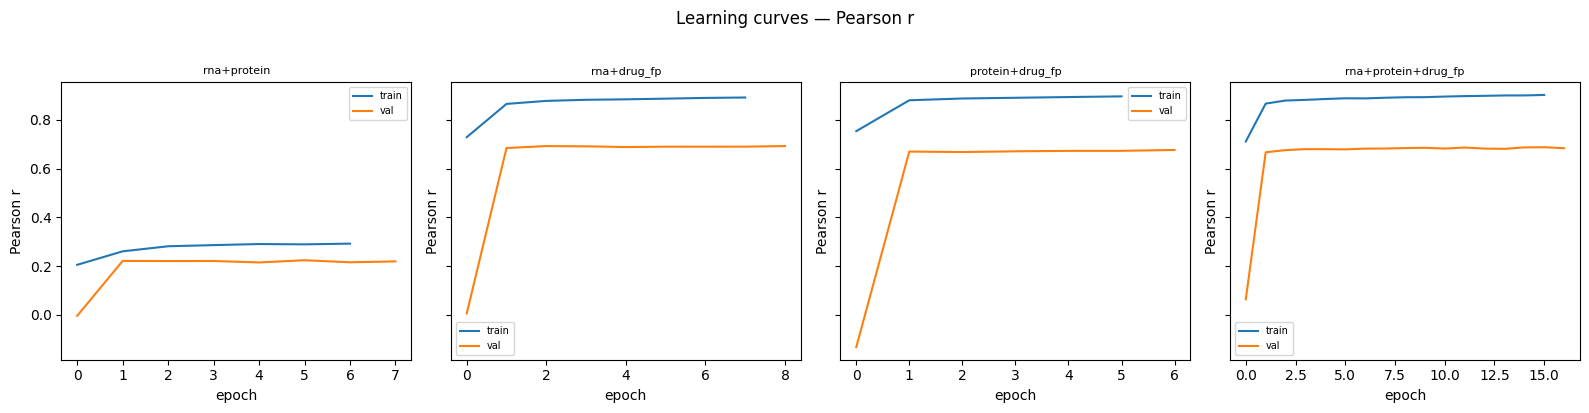

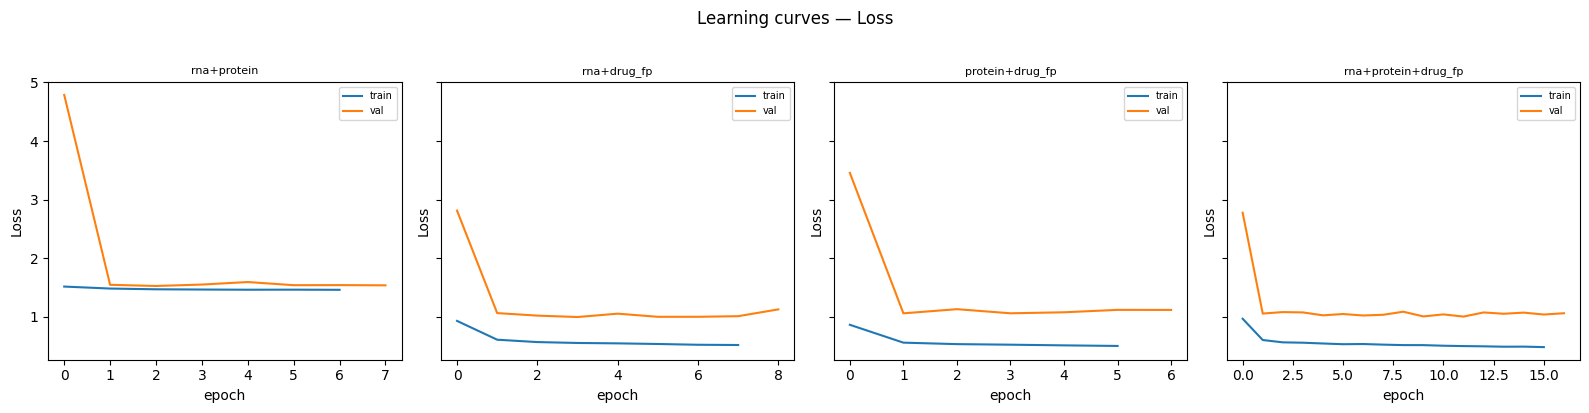

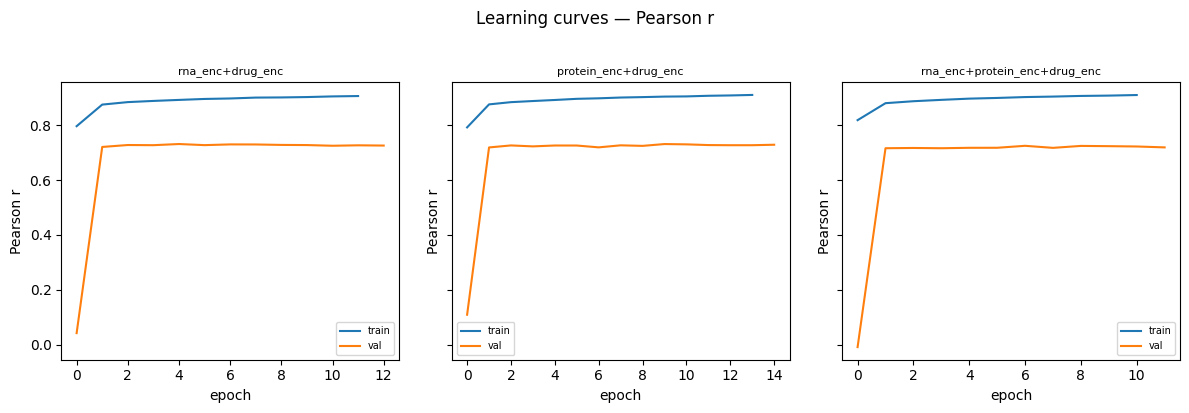

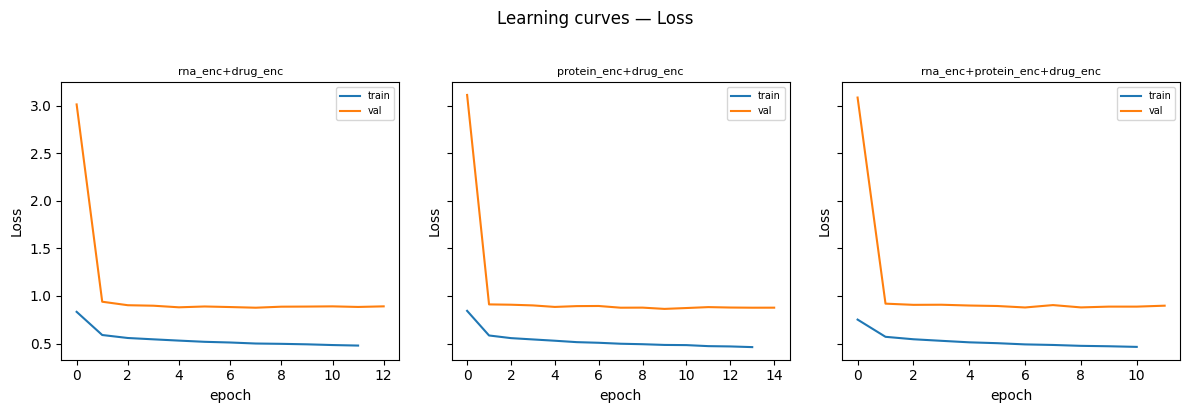

In [67]:
def plot_learning_curves(histories: dict, metric: str = 'cor') -> None:
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]
    ylabel = 'Pearson r' if metric == 'cor' else 'Loss'
    for ax, (arm_name, hist) in zip(axes, histories.items()):
        ax.plot(hist[f'train_{metric}'], label='train')
        ax.plot(hist[f'val_{metric}'],   label='val')
        ax.set_title(arm_name, fontsize=8)
        ax.set_xlabel('epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
    plt.suptitle(f'Learning curves — {ylabel}', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'learning_curves_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

# Tier 1 — raw concat
tier1_histories = {
    'rna+protein':         arm1_history,
    'rna+drug_fp':         arm2_history,
    'protein+drug_fp':     arm3_history,
    'rna+protein+drug_fp': arm4_history,
}
plot_learning_curves(tier1_histories, metric='cor')
plot_learning_curves(tier1_histories, metric='loss')

# Tier 2 — encoder-projected concat
tier2_histories = {
    'rna_enc+drug_enc':              arm5_history,
    'protein_enc+drug_enc':          arm6_history,
    'rna_enc+protein_enc+drug_enc':  arm7_history,
}
plot_learning_curves(tier2_histories, metric='cor')
plot_learning_curves(tier2_histories, metric='loss')